# Cadence Signal Workflow

Cadences encode a sequence of compatible observations. This
notebook builds an ordered ABACAD-style cadence, injects only into
the on-target frames, checks the off-target frames, and consolidates
the result for a single dynamic-spectrum view.

In [7]:
%matplotlib inline

from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib
_ipython = get_ipython()
if _ipython is not None:
    _ipython.run_line_magic("matplotlib", "inline")
    matplotlib.use("module://matplotlib_inline.backend_inline", force=True)

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

import setigen as stg

OUT = Path("generated")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=4, suppress=True)
print("matplotlib backend:", matplotlib.get_backend())
print("setigen from:", stg.__file__)

matplotlib backend: module://matplotlib_inline.backend_inline
setigen from: /Users/bryanbrzycki/Code/seti/setigen/setigen/__init__.py


In [8]:
from astropy.time import Time

In [9]:
mjd_start = 60000
obs_length = 120
slew_time = 15
starts = [Time(mjd_start, format="mjd").unix]
for _ in range(1, 6):
    starts.append(starts[-1] + obs_length + slew_time)

frames = []
for i, start in enumerate(starts):
    fr = stg.Frame(
        fchans=512,
        tchans=16,
        df=2 * u.Hz,
        dt=(obs_length / 16) * u.s,
        fch1=6_000_001_022 * u.Hz,
        ascending=False,
        t_start=start,
        source_name=f"Obs{i}",
        seed=i,
    )
    fr.add_noise(10, noise_type="chi2")
    frames.append(fr)

cadence = stg.OrderedCadence(frames, order="ABACAD")
[(frame.source_name, frame.metadata.get("order_label")) for frame in cadence]

[('Obs0', 'A'),
 ('Obs1', 'B'),
 ('Obs2', 'A'),
 ('Obs3', 'C'),
 ('Obs4', 'A'),
 ('Obs5', 'D')]

In [10]:
on_target = cadence.by_label("A")
reference = cadence[0]
on_target.add_signal(
    stg.constant_path(
        f_start=reference.get_frequency(reference.fchans // 2),
        drift_rate=0.2 * reference.unit_drift_rate,
    ),
    stg.constant_t_profile(level=reference.get_intensity(snr=80)),
    stg.sinc2_f_profile(width=2 * reference.df, trunc=False),
    stg.constant_bp_profile(level=1),
    doppler_smearing=True,
)

peak_by_frame = [float(np.max(stg.spectrum(frame, mode="sum").data)) for frame in cadence]
list(zip([frame.metadata.get("order_label") for frame in cadence], peak_by_frame))

[('A', 324.6036640596677),
 ('B', 188.34377210109517),
 ('A', 336.4813730310127),
 ('C', 180.8714866721254),
 ('A', 323.8596377309551),
 ('D', 181.08418915660434)]

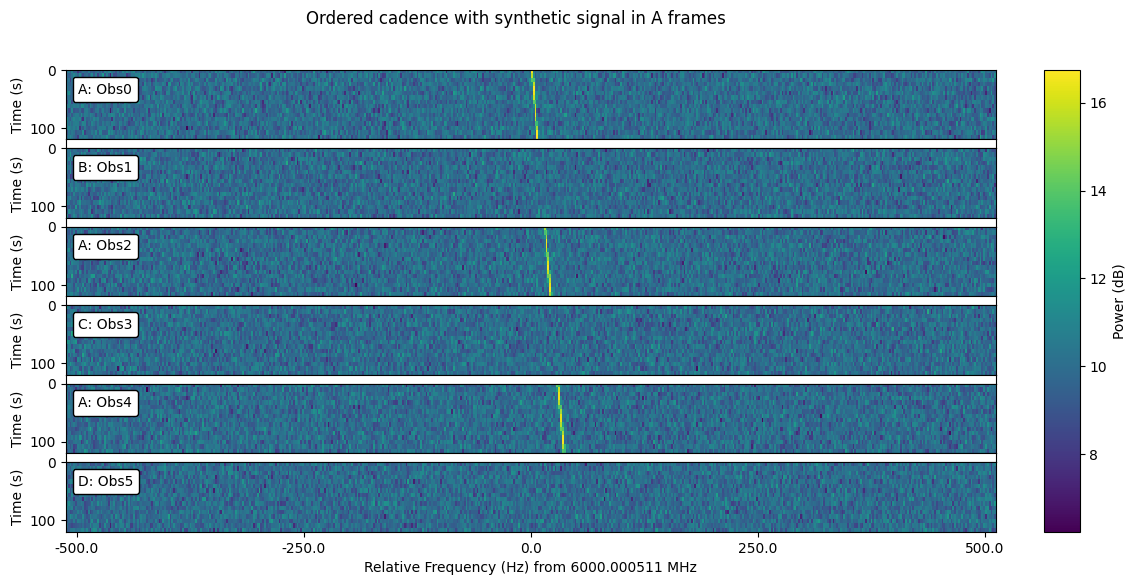

In [11]:
fig = plt.figure(figsize=(12, 6))
cadence.plot(ftype="fmid", slew_times=True, db=True)
plt.suptitle("Ordered cadence with synthetic signal in A frames")
display(fig)
plt.close(fig)

consolidated shape: (96, 512)
cadence observation span, s: 795.0


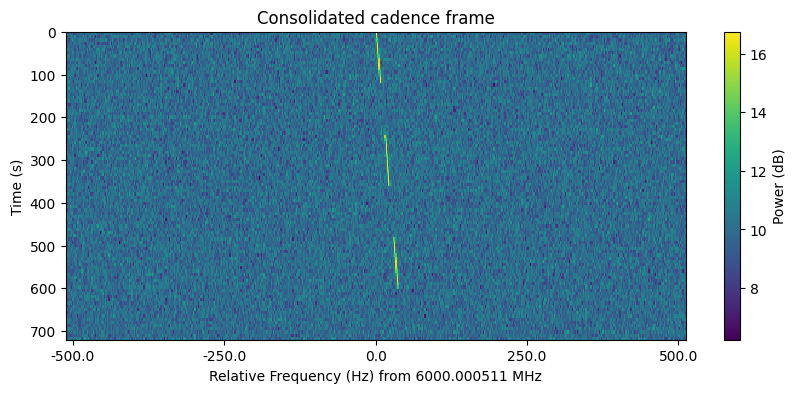

In [12]:
consolidated = cadence.consolidate()
print("consolidated shape:", consolidated.shape)
print("cadence observation span, s:", cadence.obs_range)

fig, ax = plt.subplots(figsize=(10, 4))
consolidated.plot(ftype="fmid", ttype="trel", db=True, colorbar=True)
ax.set_title("Consolidated cadence frame")
display(fig)
plt.close(fig)